I linear_regression

Mục tiêu của xây dựng một hàm dự đoán đơn giản dựa vào các tham số tuyến tính với nhau  
Ví dụ như : dự đoán giá nhà khi biết diện tích , vị trí nhà ở , số phòng ngủ , số phòng khách,...

phương trình của hàm tuyến tính sẽ  có dạng 
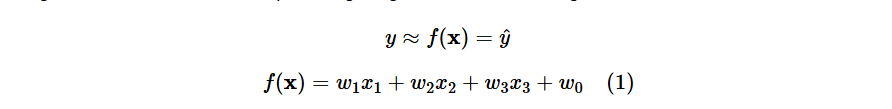

Suy ra hàm biểu mục tiêu của hồi quy tuyến tính 

$(h_{\theta}(x) -y)^2$

mục tiêu của chúng ta là làm minimize hàm này cho giá trị nhỏ nhất nghĩa là giảm thiếu nhất sự chênh lệch giữa giá trị dự đoán và giá trị thực tế 

Từ đó ta xây dựng lên hàm mất mát 

$L(w) = \frac{1}{2N} \sum_{i=1}^{N} (y_i - x^T_i w)^2$  
giá trị $\frac{1}{2N}$ là tham số trong hàm mất mát nó tính giá trị trung bình giúp tránh hiện tượng tràn số khi số lượng điểm  dữ liệu lớn 

Thuật toán sử dụng : Gradient descent  
sử dụng tính chất của gradient (luôn hướng đến trung tâm của mô hình) nên ta chỉ cần đi theo hướng ngược lại của gradient thì sẽ tìm được giá trị nhỏ nhất của hàm mục tiêu  

tính theo công thức 
$ w_{j+1} = w_{j} - \alpha * gradient(L(w)) \\
\alpha : learning \space rate$


Giải tìm nghiệm của hàm mất mát theo toán học  
kết quả đạo hàm của hàm mất mát:  
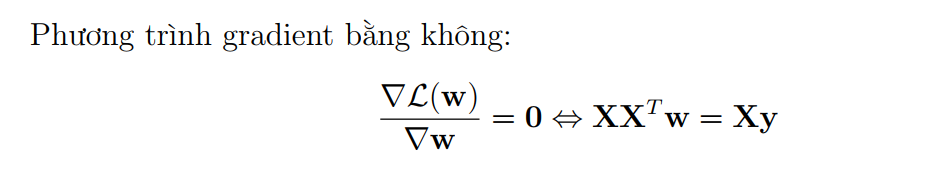  
nếu ma trận vuông $XX^T$ khả nghịch phương trình sẽ có nghiệm duy nhất $w = (XX^T)^{-1}Xy$
nếu ma trận $XX^T$ không khả nghịch thì phương trình sẽ có vô nghiệm or có vô số nghiệm khi đó người ta chứng minh được rằng 

Tồn tại giá trị w có chuẩn chắc chắn làm giá trị $(y_i -x^T_iw)^2$ đạt giá trị nhỏ nhất cụ thể  
$w = (XX^T)^\dagger Xy$  
với $\dagger$ là giải nghịch đảo của ma trận $XX^T$ 

ở trong phương trình (1) tham số $w_0$ ở đây chính là hệ số điều chỉnh (bias) của hàm số t có thể điều chỉnh bias để mô hình trở nên linh hoạt hơn  
Ta sẽ thêm $x_0$ bằng 1 vào vector đặc trưng và ghép hệ số điều chỉnh b vào vector trọng số w => thủ thuật gộp hệ số điều chỉnh (bias trick) 

Ví dụ bài toán 
giả sử có dữ liệu cân nặng và chiều cao của 15 người. Dữ liệu của hai người có chiều cao 155cm và 160 cm được tách ra làm tập kiểm tra, phần còn lại tạo thành tập huấn luyện. Bài toán đặt ra là liệu có thể dự đoán cân nặng của một người dựa vào chiều cao của họ không? có thể thấy cân nặng thường tỉ lệ thuận theo chiều cao,

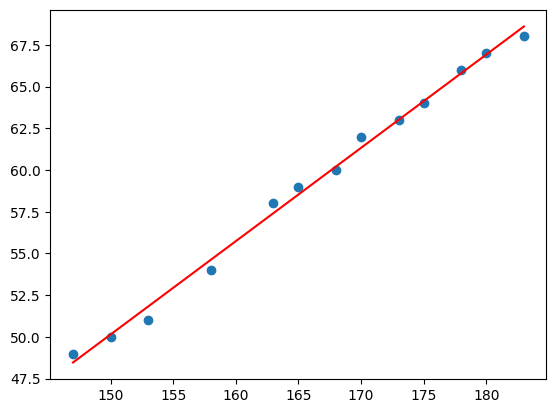

In [2]:
import numpy as np
import matplotlib.pyplot as plt 

# chuan bi feature cho dữ liệu 
X = np.array([[147, 150, 153, 158, 163, 165, 168, 170, 173, 175, 178, 180,
183]]).reshape(-1,1)
y = np.array([[ 49, 50, 51, 54, 58, 59, 60, 62, 63, 64, 66, 67, 68]]).reshape(-1,1)


one = np.ones((X.shape[0],1))
Xbar = np.concatenate((one, X), axis = 1)

#theo cong thuc 
A = np.dot(Xbar.T, Xbar)
b = np.dot(Xbar.T, y)

w = np.dot(np.linalg.pinv(A), b) # tinh ra nghiem cua phuong trinh hoi quy tuyen tinh luon 

w_0 , w_1 = w[0], w[1]

y1 = w_1*155 + w_0
y2 = w_1*160 + w_0

plt.scatter(X, y)
plt.plot(X, w_0 + w_1*X, 'r')
plt.show()


Output: Input 155cm, true output 52kg, predicted output 52.94kg.  
&nbsp;&nbsp;&nbsp;&nbsp;Input 160cm, true output 56kg, predicted output 55.74kg.

In [7]:
from sklearn import datasets, linear_model # fit the model by Linear Regression
regr = linear_model.LinearRegression()
regr.fit(X, y) # in scikit-learn, each sample is one row
print("scikit-learn’s solution: w_1 = ", regr.coef_[0], "w_0 = ",\
regr.intercept_)
print("our solution:  w_1 = " , w_1, "        w_o =", w_0)

scikit-learn’s solution: w_1 =  [0.55920496] w_0 =  [-33.73541021]
our solution:  w_1 =  [0.55920496]         w_o = [-33.73541021]


hạn chế 1: Rất nhạy cảm với nhiễu ( sensitive to noise)  có thể khắc phục bằng cách loại bỏ các nhiễu trong quá trình tìm nghiệm ( phức tạp và tốn thời gian ) có một cách khác là sử dụng mất mát HUBER ( hồi quy Huber)  
https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.HuberRegressor.html  
hạn chế 2: nó không biểu diễn được các mô hình phức tạp (rất khó khắc phục  thuật toán này ít khả quan trong thực tế )  
=> ta cần kiểm tra giả định & xử lý: phi tuyến , tự tương quang , phương sai thay đổi , ngoại lai /đòn bẩy cao , đồng tuyến. Trong hồi quy tuyến tính hãy tránh nhiều nhất có thể 


Lưu ý lớn nhất trong huẩn luận ML là lựa chọn tập đặc trưng sao cho hợp lý và trong hồi quy tuyến tính cũng vậy. Để tìm được tập đặc trưng thỏa mãn ta cần trả lời các câu hỏi sau   
1. tham số nào là hữu ích tham số nào ảnh hướng tuyến tính đến mô hình 
2. Feature này có cung cấp thông tin mới không?
3. Feature này có dễ thu thập trong thực tế không?
4. Feature này có gây rò rỉ dữ liệu (data leakage) không?
5. Feature có bị thiếu dữ liệu nhiều không?
6. Feature có cần biến đổi (feature engineering) không?
7. Feature có bị nhiễu hoặc sai số lớn không?
8. Feature có giúp mô hình đơn giản hơn không?